In [3]:
import h5py
import yaml
import numpy as np

with h5py.File("pixsplit_data/train/nparticles_resampled.h5", "r") as f:
    for key in f.keys():
        print(f"{key}: {f[key].shape}")

barrelec: (3304287, 1)
charge: (3304287, 49)
last_phi: (3304287, 1)
last_theta: (3304287, 1)
layer: (3304287, 1)
mean_phi: (3304287, 1)
mean_theta: (3304287, 1)
nparticles: (3304287, 1)
pitches: (3304287, 7)


In [ ]:
import h5py
import numpy as np
import yaml
import tensorflow as tf

# Using yaml 'mean' and 'std' values for normalization
# Z-Score Normalization / Standardization
with open("pixsplit_data/train/nparticles_resampled.yaml", "r") as f:
    meta = yaml.safe_load(f)

def load_split(folder_path):
    h5_path = f"{folder_path}/nparticles_resampled.h5"
    
    with h5py.File(h5_path, "r") as hf:
        # --- Y (Labels) ---
        y_int = (hf['nparticles'][:] - 1).astype(np.int32).flatten()
        y = tf.keras.utils.to_categorical(y_int, num_classes=3)

        # --- X1 (Charge Matrix) ---
        c_mean = np.array(meta['charge']['mean'], dtype=np.float32)
        c_std  = np.array(meta['charge']['std'], dtype=np.float32)
        X1 = (hf['charge'][:] - c_mean) / c_std

        # --- X2 (Context Vector) ---
        # Pitches
        p_mean = np.array(meta['pitches']['mean'], dtype=np.float32)
        p_std  = np.array(meta['pitches']['std'], dtype=np.float32)
        norm_pitches = (hf['pitches'][:] - p_mean) / p_std
        
        # Angles
        phi_mean = np.array(meta['mean_phi']['mean'], dtype=np.float32)
        phi_std  = np.array(meta['mean_phi']['std'], dtype=np.float32)
        norm_phi = (hf['mean_phi'][:] - phi_mean) / phi_std

        theta_mean = np.array(meta['mean_theta']['mean'], dtype=np.float32)
        theta_std  = np.array(meta['mean_theta']['std'], dtype=np.float32)
        norm_theta = (hf['mean_theta'][:] - theta_mean) / theta_std

        # Categorical Flags
        raw_layer = hf['layer'][:].astype(np.float32)
        raw_bec   = hf['barrelec'][:].astype(np.float32)

        # Stack into (N, 11) context vector
        X2 = np.hstack([norm_pitches, norm_phi, norm_theta, raw_layer, raw_bec])
        X = np.hstack([X1, X2])  
    return X, y

X_train, y_train = load_split("pixsplit_data/train")
X_val, y_val     = load_split("pixsplit_data/val")
X_test, y_test   = load_split("pixsplit_data/test")

print(f"Loaded {len(y_train)} training samples.")
print(f"Loaded {len(y_val)} validation samples.")

Loaded 3304287 training samples.
Loaded 413034 validation samples.


In [22]:
import numpy as np
import os

# Create a directory for our processed data
os.makedirs("processed_data", exist_ok=True)

# Save Training Set
np.save("processed_data/X_train.npy", X_train)
np.save("processed_data/y_train.npy", y_train)

# Save Validation Set
np.save("processed_data/X_val.npy", X_val)
np.save("processed_data/y_val.npy", y_val)

# Save Test Set
np.save("processed_data/X_test.npy", X_test)
np.save("processed_data/y_test.npy", y_test)

print("All files saved to /processed_data/")

All files saved to /processed_data/


In [2]:
import numpy as np
from hgq.utils.sugar import Dataset

X_train = np.load("processed_data/X_train.npy")
X_val = np.load("processed_data/X_val.npy")
X_test = np.load("processed_data/X_test.npy")
y_train = np.load("processed_data/y_train.npy")
y_val = np.load("processed_data/y_val.npy")
y_test = np.load("processed_data/y_test.npy")


#dataset_train = Dataset(X_train, y_train, batch_size=33200, device='gpu:0')
#dataset_val = Dataset(X_val, y_val, batch_size=33200, device='gpu:0')
#dataset_test = Dataset(X_test, y_test, batch_size=33200, device='gpu:0')

In [5]:
import numpy as np

print("Min:", np.min(X_train, axis=0))
print("Max:", np.max(X_train, axis=0))
print("Mean:", np.mean(X_train, axis=0))
print("Std:", np.std(X_train, axis=0))

Min: [-6.66591385e-03 -2.30903864e-01 -1.15151262e+00 -5.17567694e-01
 -2.50182331e-01 -1.34379125e+00 -7.39089493e-03 -3.89694881e+00
 -7.68431246e-01 -4.45926040e-01 -3.06183010e-01 -2.89837778e-01
 -8.56859982e-01 -1.76783717e+00 -2.01135659e+00 -7.12272406e-01
 -2.23661852e+00 -1.06896901e+00 -4.23719913e-01 -6.98117554e-01
 -7.49217629e-01 -1.46231365e+00 -5.48480034e-01 -2.01807404e+00
 -9.10737872e-01 -4.36225027e-01 -5.44422328e-01 -1.38661981e+00
 -9.96341228e-01 -6.72614038e-01 -4.05758470e-01 -1.44357562e+00
 -3.88913900e-01 -6.33282900e-01 -1.81195164e+00 -1.66862775e-02
 -1.42858911e+00 -2.88812399e+00 -3.06671888e-01 -4.56159830e-01
 -9.19447958e-01 -4.83223486e+00 -4.77379560e+00 -1.36191630e+00
 -1.06710684e+00 -4.47508216e-01 -5.58119297e-01 -1.62710920e-02
 -3.94378137e-03 -6.38158131e+00 -4.12914753e+00 -2.10211635e+00
 -1.31545424e+00 -2.11264038e+00 -4.14486027e+00 -6.42809629e+00
 -5.47133058e+00 -2.22274665e+00  0.00000000e+00 -2.00000000e+00]
Max: [386.10934448 

In [ ]:
from keras import layers, models

model = models.Sequential([
    layers.Input(shape=(60,)),
    
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    
    layers.Dense(64, activation='relu', name="encoder_layer"),
    
    layers.Dense(3, activation='softmax')
])
model.summary()

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 128)            │         7,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_layer (Dense)           │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,451 (79.89 KB)

 Trainable params: 20,451 (79.89 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
from keras.callbacks import LearningRateScheduler

import math

def aggressive_early_decay(initial_lr=5e-3, first_decay_epochs=10, t_mul=2.0, m_mul=0.5):
    def schedule(epoch):
        n_cycle = 1
        cycle_step = epoch
        cycle_len = first_decay_epochs
        
        # Calculate which restart cycle we are in
        while cycle_step >= cycle_len:
            cycle_step -= cycle_len
            cycle_len *= t_mul
            n_cycle += 1

        # Cosine decay math
        cycle_t = min(cycle_step / cycle_len, 1.0)
        lr = 0.5 * initial_lr * (1 + math.cos(math.pi * cycle_t)) * (m_mul ** (n_cycle - 1))
        
        # Floor it at 1e-6 so learning doesn't totally stall
        return max(lr, 1e-6)
    
    return schedule

# 100 Epoch Run: Cycles will end at Epoch 15, 45, and then go beyond 100.
lr_callback = LearningRateScheduler(
    aggressive_early_decay(initial_lr=5e-3, first_decay_epochs=10, t_mul=2.0, m_mul=0.5)
)

In [15]:
# In original project: Epochs = 128, batch_size = 1000
model.fit(X_train, y_train, validation_data=(X_val, y_val), callbacks=[lr_callback], epochs=100, batch_size=1024)

Epoch 1/100


2026-04-07 18:44:38.553289: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_421_0', 4 bytes spill stores, 4 bytes spill loads

2026-04-07 18:44:38.750972: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_243', 8 bytes spill stores, 8 bytes spill loads

2026-04-07 18:44:39.453310: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_423', 124 bytes spill stores, 120 bytes spill loads

2026-04-07 18:44:39.486280: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_423', 2900 bytes spill stores, 2908 bytes spill loads

2026-04-07 18:44:39.706776: I external/local_xla/xla/stream_

3218/3227 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7439 - loss: 0.5784

2026-04-07 18:44:55.530309: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_243', 8 bytes spill stores, 8 bytes spill loads

2026-04-07 18:44:55.806761: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_367', 4 bytes spill stores, 4 bytes spill loads

2026-04-07 18:44:56.745226: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_421', 36 bytes spill stores, 36 bytes spill loads

2026-04-07 18:44:56.848624: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_423', 572 bytes spill stores, 576 bytes spill loads

2026-04-07 18:44:56.917931: I external/local_xla/xla/stream_execut

3227/3227 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7440 - loss: 0.5783

2026-04-07 18:45:02.121725: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_79', 8 bytes spill stores, 8 bytes spill loads



3227/3227 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - accuracy: 0.7600 - loss: 0.5439 - val_accuracy: 0.7735 - val_loss: 0.5151 - learning_rate: 0.0050
Epoch 2/100
3227/3227 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.7740 - loss: 0.5139 - val_accuracy: 0.7758 - val_loss: 0.5084 - learning_rate: 0.0049
Epoch 3/100
3227/3227 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.7786 - loss: 0.5047 - val_accuracy: 0.7765 - val_loss: 0.5075 - learning_rate: 0.0045
Epoch 4/100
3227/3227 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.7819 - loss: 0.4980 - val_accuracy: 0.7780 - val_loss: 0.5033 - learning_rate: 0.0040
Epoch 5/100
3227/3227 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.7845 - loss: 0.4925 - val_accuracy: 0.7823 - val_loss: 0.4963 - learning_rate: 0.0033
Epoch 6/100
3227/3227 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - accuracy: 0.7875 - loss: 0.4872 - val_accuracy: 0.7825 - val_loss: 0.4960 - learning_rate: 0.0025
Epoch 7/100
3227/3227 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.7897 -

KeyboardInterrupt: 

In [27]:
score = model.evaluate(X_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

Test loss: 0.49567028880119324
Test accuracy: 0.7831921577453613


In [28]:
y_pix = model.predict(X_test)

12908/12908 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step


<Figure size 800x600 with 0 Axes>

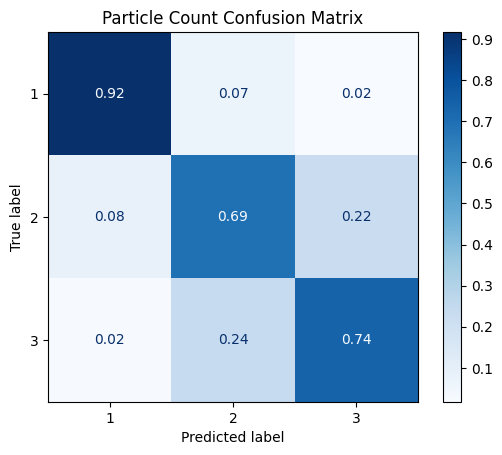

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(y_pix, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred, normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1, 2, 3])

plt.figure(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, values_format='.2f') # .2f shows 2 decimal places for percentages
plt.title('Particle Count Confusion Matrix')
plt.show()